# Diagrama P-v modelado con PRSV para Deueterio (D₂)
---

In [2]:
! pip install thermo
! pip install chemicals

   ---------------------------------------- 0.0/6.4 MB ? eta -:--:--
   ------------- -------------------------- 2.1/6.4 MB 11.7 MB/s eta 0:00:01
   --------------------------- ------------ 4.5/6.4 MB 11.7 MB/s eta 0:00:01
   -------------------------------- ------- 5.2/6.4 MB 11.4 MB/s eta 0:00:01
   ---------------------------------------- 6.4/6.4 MB 8.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import thermo
import chemicals
from scipy.integrate import quad

CAS_NUMBER = chemicals.search_chemical('deuterium').CASs
Pc =  chemicals.Pc(CAS_NUMBER) # [Pa]
Tc = chemicals.Tc(CAS_NUMBER) # [K]
k1 = 0 #fuente que estudio el uso de diferentes ecuaciones de estado para el hidrogeno, asigno esto, y el hidrogeno similar al deuterio
w = chemicals.omega(CAS_NUMBER)
R = 8.3145 # [J/molK]


* PSRV for P


In [ ]:
def alfaF(T, Tc, w, k1):
    m = 0.378893 + 1.4897153*w -0.171384*w**2 + 0.0196554*w**3
    return (1+m*(1-(T/Tc)**0.5) + k1*(1-(T/Tc))*(0.7-(T/Tc)))**2

def PSRV_P(v, alfa, T, R, Tc, Pc):
    ac = 0.45724*((R*Tc**2.5)/Pc)
    b = 0.07780*R*Tc/Pc
    return (R*T/(v-b)) + ((ac*alfa)/(v*(v+b) + b*(v-b)))

def PSRV_V(alfa, T, R, Tc, P, Pc):
    ac = 0.45724*(R*Tc**2.5/Pc)
    b = 0.07780*R*Tc/Pc
    c2 = (P*b - R*T)/P 
    c1 = (alfa*ac-3*P*b**2 - 2*R*T*b)/P
    c0 = (P*b**3 + R*T*b**2 - alfa*ac*b)/P
    roots =  np.roots([1,c2, c1, c0])
    # rootsThermo = thermo.eos.PRSV(Tc, Pc, w, T, P, k1)
    return roots[np.isclose(roots.imag, 0)].real

alfa = alfaF(298.15, Tc, w, k1)
print(PSRV_V(alfa, 298.15, R, Tc, 101325, Pc))



[153.74573508338548, 101325, 1.4765158312883526e-05, 2.953031662576705e-05, -2.1800990000451348e-10, 0.018896586138073924, 'coordinates of failure']
[153.74573508338548, 101325, 1.4765158312883526e-05, 2.953031662576705e-05, -2.1800990000451348e-10, 0.018896586138073924, 'coordinates of failure']
[153.74573508338548, 101325, 1.4765158312883526e-05, 2.953031662576705e-05, -2.1800990000451348e-10, 0.018896586138073924, 'coordinates of failure']
[153.74573508338548, 101325, 1.4765158312883526e-05, 2.953031662576705e-05, -2.1800990000451348e-10, 0.018896586138073924, 'coordinates of failure']
[153.74573508338548, 101325, 1.4765158312883526e-05, 2.953031662576705e-05, -2.1800990000451348e-10, 0.018896586138073924, 'coordinates of failure']
[153.74573508338548, 101325, 1.4765158312883526e-05, 2.953031662576705e-05, -2.1800990000451348e-10, 0.018896586138073924, 'coordinates of failure']


* Criterio de Maxwell para el Equilibrio


In [ ]:
def maxwellAreas(vv, vl, P, T, R, Tc, Pc, alfa):
    return np.abs(P*(vv - vl) - quad(PSRV_P,  vl, vv, args=(alfa, T, R, Tc, Pc))[0]) < 10**-3

* Calculo de fugacidad para PRSV
 

In [29]:
def func(v,T, alfa, ac, b, R):
    return v*((-R*T)/(v-b)**2 - (ac*alfa*(2*v + 2*b)/((v**2+v*b+b*v-b**2)**2)))


def f(alfa, T, R, v):
    vinf = np.max(PSRV_V(alfa, T, R, Tc, 5, Pc))
    ac = 0.45724*(8.3145*Tc**2.5/Pc)
    b = 0.07780*R*Tc/Pc
    return np.exp((quad(func, vinf, v, args=(T, alfa, ac, b, R))/(R*T))[0]) * (Pc/100)


* PRSV for V and Execution

ValueError: 0 is not in list

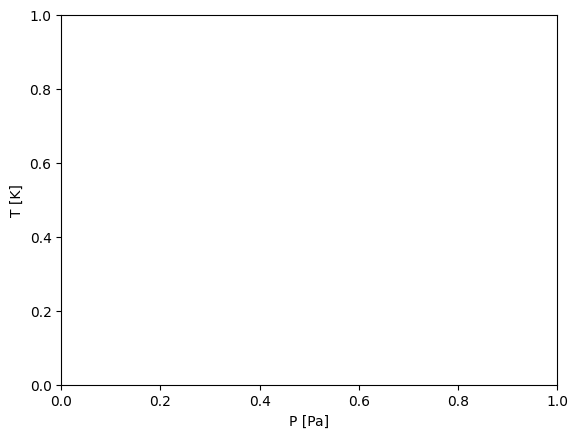

In [ ]:
T_array = np.linspace(10, 2*Tc, 11) #K
P_array = np.linspace(10, 1.5*Pc, 100000) #Pa


plt.figure()
plt.xlabel('P [Pa]')
plt.ylabel('T [K]')

def plotter(t, P_array, v, split_value):
    idx = v.index(split_value)
    line, = plt.plot(P_array[:idx], v[:idx], label=f"T(K)= {t:.1f}")
    color = line.get_color()
    plt.plot(P_array[idx+1:], v[idx+1:], color = color)
    plt.hlines(y=P_array[idx], xmin=v[idx][0], xmax=v[idx][2], colors=color, linestyles='solid')
    


for t in T_array:
    alfa = alfaF(t, Tc, w, k1)
    v = []
    split_value = 0
    for p in P_array: 
        roots = PSRV_V(alfa, t, R, Tc, p, Pc)
        if len(roots) == 1:
            v.append(roots[0])
        elif len(roots) == 3:
            if maxwellAreas(np.max(roots),np.min(roots), p,t,R, Tc, Pc, alfa):
                split_value = (np.min(roots), np.max(roots)) 
                v.append(split_value)
            else: 
                fv = f(alfa, t, R, np.max(roots))
                fl = f(alfa, t, R, np.min(roots))
                if fv < fl:
                    v.append(np.max(roots))
                elif fl < fv:
                    v.append(np.min(roots))
    plotter(t, P_array, v, split_value)

plt.legend(fontsize=10)
    
